In [1]:
from google.colab import drive
drive.mount('/content/drive')
#drive.mount('/content/drive', force_remount=True)

mat_path = '/content/drive/MyDrive/Colab Notebooks/SCR/NEDC_lite.mat'

Mounted at /content/drive


Starting simulation... It takes around 1 min, JP
Simulation finished.
AdBlue source used: controller
RMSE(model rear sensor vs measured rear NOx sensor): 14.0816 ppm
MSE(model rear sensor vs measured rear NOx sensor): 198.2908
Controller vs adblue_mg correlation: 0.998529


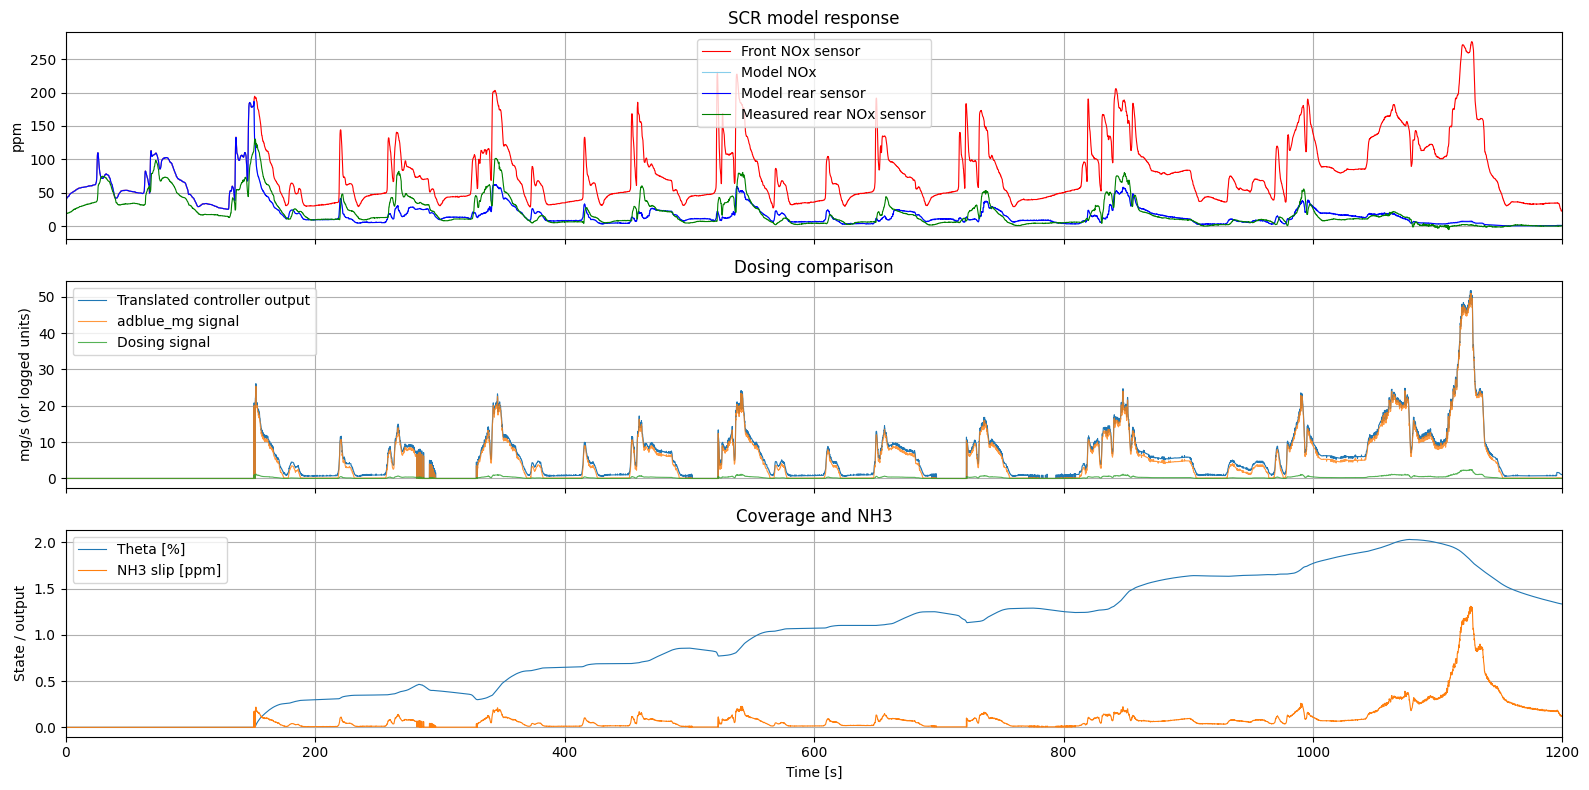

In [3]:
from __future__ import annotations

import math
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.integrate import solve_ivp


# ---------- Lookup tables copied from the Simulink model ----------
NO_RATIO_BP = np.array(
    [131.3121, 161.1298, 224.8357, 265.8866, 322.246, 363.2026, 415.0273, 469.8143, 511.78],
    dtype=float,
)
NO_RATIO_TBL = np.array(
    [0.785714, 0.979592, 0.360825, 0.324138, 0.366906, 0.497227, 0.617626, 0.702214, 0.761749],
    dtype=float,
)

DENSITY_BP = np.array(
    [260, 280, 300, 350, 400, 450, 500, 600, 800, 1000, 1200, 1400], dtype=float
)
DENSITY_TBL = np.array(
    [1.340, 1.245, 1.161, 0.995, 0.871, 0.774, 0.696, 0.580, 0.435, 0.348, 0.290, 0.249],
    dtype=float,
)

PARAMS = {
    # Top-level constants from the Simulink model
    "k_std_0": 3.59e9,
    "k_fst_0": 8.80e9,
    "k_slw_0": 3.56e11,
    "k_ads_0": 4.32,
    "k_des_0": 4.83e4,
    "k_nh3ox_0": 6.99e5,
    # Activation energies from subsystem 15
    "E1": 77300.0,
    "E2": 45200.0,
    "E3": 109000.0,
    "E4": -10200.0, #- 7000.0,
    "E5": 67500.0,
    "E6": 91100.0,
    "R": 8.314,
    # Reactor constants
    "volume_m3": 0.000899,
    "ohm": 900.0,
    # Feedforward controller thresholds
    "switch_temp_scr_c": 190.0,
    "switch_no_ratio": 0.5,
}


def lookup(x: np.ndarray | float, bp: np.ndarray, table: np.ndarray) -> np.ndarray | float:
    return np.interp(x, bp, table, left=table[0], right=table[-1])


def load_timeseries(mat_dict: Dict, name: str) -> Tuple[np.ndarray, np.ndarray]:
    """Extract a Simulink Structure With Time saved in a .mat file."""
    obj = mat_dict[name][0, 0]
    t = np.asarray(obj["time"]).squeeze().astype(float)
    v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
    return t, v


def deduplicate_time(t: np.ndarray, *signals: np.ndarray) -> Tuple[np.ndarray, ...]:
    """Keep the first sample at duplicated timestamps for ODE integration."""
    _, first_idx = np.unique(t, return_index=True)
    first_idx = np.sort(first_idx)
    out = [t[first_idx]]
    for s in signals:
        out.append(s[first_idx])
    return tuple(out)


def ppm_to_molm3(ppm: np.ndarray | float) -> np.ndarray | float:
    return ppm / 22.4 / 1000.0


def molm3_to_ppm(c: np.ndarray | float) -> np.ndarray | float:
    return c * 1000.0 * 22.4


def rate_constants(temp_c: np.ndarray | float):
    """
    Translate subsystem 15:
        k = k0 * exp(-E / (R*T))
    where T = temp_C + 273.15.
    """
    p = PARAMS
    T = np.asarray(temp_c, dtype=float) + 273.15
    k_std = p["k_std_0"] * np.exp(-p["E1"] / (p["R"] * T))
    k_fst = p["k_fst_0"] * np.exp(-p["E2"] / (p["R"] * T))
    k_slw = p["k_slw_0"] * np.exp(-p["E3"] / (p["R"] * T))
    k_ads = p["k_ads_0"] * np.exp(-p["E4"] / (p["R"] * T))
    k_des = p["k_des_0"] * np.exp(-p["E5"] / (p["R"] * T))
    k_nh3ox = p["k_nh3ox_0"] * np.exp(-p["E6"] / (p["R"] * T))
    return T, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox


def gas_exchange_factor(exhaust_mg_s: np.ndarray | float, temp_c: np.ndarray | float):
    """
    Translate subsystem 15 path that computes:
        T[K], density(T), F = Q / V
    where:
        exhaust_kg_s = exhaust_mg_s * 1e-6
        Q = exhaust_kg_s / density
        F = Q / reactor_volume
    """
    T, *_ = rate_constants(temp_c)
    rho = lookup(T, DENSITY_BP, DENSITY_TBL)
    exhaust_kg_s = np.asarray(exhaust_mg_s, dtype=float) * 1e-6
    q_m3_s = exhaust_kg_s / np.maximum(rho, 1e-12)
    F = q_m3_s / PARAMS["volume_m3"]
    return T, rho, F


def feedforward_adblue(
    temp_doc_up_c: np.ndarray,
    nox_f_ppm: np.ndarray,
    exhaust_mg_s: np.ndarray,
    temp_scr_up_c: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Translate subsystem Feedforward_controller.

    Returns
    -------
    adblue_mg_s : np.ndarray
        Feedforward AdBlue command [mg/s]
    no_ratio : np.ndarray
        NO/(NO+NO2) ratio from the temperature lookup table
    """
    no_ratio = lookup(temp_doc_up_c, NO_RATIO_BP, NO_RATIO_TBL)

    mw_no = 14.007 + 15.999
    mw_no2 = 14.007 + 15.999 * 2.0
    mw_nh3 = 14.007 + 1.008 * 3.0
    mw_exh = 29.47

    # Simulink Fcn blocks
    c_ratio = (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2) / mw_exh
    nh3_vs_nox_ratio = mw_nh3 / (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2)

    # Simulink Product blocks
    exhaust_kg_s = exhaust_mg_s * 1e-6
    nox_mass_like = c_ratio * nox_f_ppm * exhaust_kg_s
    base_nh3 = nh3_vs_nox_ratio * nox_mass_like
    extra_no2_comp = base_nh3 * (1.0 - 2.0 * no_ratio) * 0.333

    # Switch1: if NO_ratio >= 0.5 -> base_nh3, else -> base_nh3 + extra_no2_comp
    alpha_ratio = np.where(
        no_ratio >= PARAMS["switch_no_ratio"],
        base_nh3,
        base_nh3 + extra_no2_comp,
    )

    # Gain blocks: NH3 -> Urea -> AdBlue
    urea_mg_s = alpha_ratio * (60.0 / 34.0)
    adblue_mg_s = urea_mg_s * (100.0 / 32.4)

    # Switch: enable dosing only above SCR inlet temperature threshold
    adblue_mg_s = np.where(temp_scr_up_c >= PARAMS["switch_temp_scr_c"], adblue_mg_s, 0.0)
    return adblue_mg_s, no_ratio


def adblue_to_nh3_in_molm3(adblue_mg_s: np.ndarray, exhaust_mg_s: np.ndarray) -> np.ndarray:
    """
    Translate subsystem INput_data_calculate [ppm -> mol/m^3] for the NH3 path.
    """
    return (
        ((adblue_mg_s * (32.4 / 100.0) * (34.0 / 60.0)) / np.maximum(exhaust_mg_s, 1e-12))
        * 1e6
        * (28.8 / 17.0)
        / 1000.0
        / 22.4
    )


def simulate_scr(mat_path: str | Path, adblue_source: str = "controller") -> Dict[str, np.ndarray | float]:
    """
    Run the translated SCR model against the uploaded NEDC_lite.mat data.

    Parameters
    ----------
    mat_path : str | Path
        Path to NEDC_lite.mat
    adblue_source : {'controller', 'adblue_mg', 'Dosing'}
        Which dosing signal to use as the reactor NH3 input.
        'controller' reproduces the translated feedforward block from SCR_Model.slx.
        'adblue_mg' uses the measured signal from the .mat file.
        'Dosing' uses the other dosing signal from the .mat file.
    """
    mat = sio.loadmat(str(mat_path))

    t, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
    _, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")
    _, Dosing = load_timeseries(mat, "Dosing")
    _, Temp = load_timeseries(mat, "Temp")
    _, ExhaustFlow = load_timeseries(mat, "ExhaustFlow")
    _, adblue_mg = load_timeseries(mat, "adblue_mg")
    _, O2 = load_timeseries(mat, "O2")
    _, Temp_DOC_up = load_timeseries(mat, "Temp_DOC_up")

    adblue_cmd, no_ratio = feedforward_adblue(Temp_DOC_up, F_NOx_sensor, ExhaustFlow, Temp)

    if adblue_source == "controller":
        adblue_used = adblue_cmd
    elif adblue_source == "adblue_mg":
        adblue_used = adblue_mg
    elif adblue_source == "Dosing":
        adblue_used = Dosing
    else:
        raise ValueError("adblue_source must be one of: 'controller', 'adblue_mg', 'Dosing'")

    # Top-level split of front NOx into NO and NO2 using NO ratio lookup
    NO_in_ppm = no_ratio * F_NOx_sensor
    NO2_in_ppm = (1.0 - no_ratio) * F_NOx_sensor

    NO_in = ppm_to_molm3(NO_in_ppm)
    NO2_in = ppm_to_molm3(NO2_in_ppm)
    NH3_in = adblue_to_nh3_in_molm3(adblue_used, ExhaustFlow)
    O2_in = O2 * 1e-2

    # Deduplicate time for the ODE solver
    t_u, Temp_u, ExhaustFlow_u, O2_u, NO_in_u, NO2_in_u, NH3_in_u, R_NOx_u = deduplicate_time(
        t, Temp, ExhaustFlow, O2_in, NO_in, NO2_in, NH3_in, R_NOx_sensor
    )

    def interp_series(tt: float, arr: np.ndarray) -> float:
        return float(np.interp(tt, t_u, arr, left=arr[0], right=arr[-1]))

    def rhs(tt: float, y: np.ndarray) -> np.ndarray:
        # Simulink feedback paths use saturated nonnegative states
        cno, cno2, theta, cnh3 = np.maximum(y, 0.0)

        temp_c = interp_series(tt, Temp_u)
        exh = interp_series(tt, ExhaustFlow_u)
        o2 = interp_series(tt, O2_u)
        no_in_val = interp_series(tt, NO_in_u)
        no2_in_val = interp_series(tt, NO2_in_u)
        nh3_in_val = interp_series(tt, NH3_in_u)

        _, _, F = gas_exchange_factor(exh, temp_c)
        _, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox = rate_constants(temp_c)

        # SCR reaction rates from subsystem SCR SYSTEM1
        Rads = k_ads * cnh3 * (1.0 - theta) * PARAMS["ohm"]
        Rdes = k_des * theta * PARAMS["ohm"]
        Roxi = k_nh3ox * o2 * theta * PARAMS["ohm"]
        Rstd = k_std * cno * o2 * theta * PARAMS["ohm"]
        Rfst = k_fst * cno * cno2 * theta * PARAMS["ohm"]
        Rslw = k_slw * cno2 * theta * PARAMS["ohm"]

        # State equations translated from the Simulink sums and gains
        dcno = F * no_in_val - 4.0 * Rstd - 2.0 * Rfst - F * cno
        dcno2 = F * no2_in_val - 2.0 * Rfst - 3.0 * Rslw - F * cno2
        dtheta = (Rads - Rdes - 4.0 * Roxi - 4.0 * Rstd - 4.0 * Rfst - 4.0 * Rslw) / PARAMS["ohm"]
        dcnh3 = F * nh3_in_val - Rads + Rdes - 4.0 * Roxi - F * cnh3

        return np.array([dcno, dcno2, dtheta, dcnh3], dtype=float)

    sol = solve_ivp(
        rhs,
        (float(t_u[0]), float(t_u[-1])),
        y0=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        t_eval=t_u,
        method="BDF",
        rtol=1e-5,
        atol=1e-8,
    )
    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    cno_u, cno2_u, theta_u, cnh3_u = sol.y

    # Recompute rates on the unique time grid for logging/plotting
    T_u = np.zeros_like(t_u)
    rho_u = np.zeros_like(t_u)
    F_u = np.zeros_like(t_u)
    Rads_u = np.zeros_like(t_u)
    Rdes_u = np.zeros_like(t_u)
    Roxi_u = np.zeros_like(t_u)
    Rstd_u = np.zeros_like(t_u)
    Rfst_u = np.zeros_like(t_u)
    Rslw_u = np.zeros_like(t_u)

    for i in range(len(t_u)):
        cno = max(cno_u[i], 0.0)
        cno2 = max(cno2_u[i], 0.0)
        theta = max(theta_u[i], 0.0)
        cnh3 = max(cnh3_u[i], 0.0)

        T_u[i], rho_u[i], F_u[i] = gas_exchange_factor(ExhaustFlow_u[i], Temp_u[i])
        _, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox = rate_constants(Temp_u[i])

        Rads_u[i] = k_ads * cnh3 * (1.0 - theta) * PARAMS["ohm"]
        Rdes_u[i] = k_des * theta * PARAMS["ohm"]
        Roxi_u[i] = k_nh3ox * O2_u[i] * theta * PARAMS["ohm"]
        Rstd_u[i] = k_std * cno * O2_u[i] * theta * PARAMS["ohm"]
        Rfst_u[i] = k_fst * cno * cno2 * theta * PARAMS["ohm"]
        Rslw_u[i] = k_slw * cno2 * theta * PARAMS["ohm"]

    # Map solution back to the original time vector
    cno = np.interp(t, t_u, cno_u)
    cno2 = np.interp(t, t_u, cno2_u)
    theta = np.interp(t, t_u, theta_u)
    cnh3 = np.interp(t, t_u, cnh3_u)
    T_K = np.interp(t, t_u, T_u)
    rho = np.interp(t, t_u, rho_u)
    F = np.interp(t, t_u, F_u)
    Rads = np.interp(t, t_u, Rads_u)
    Rdes = np.interp(t, t_u, Rdes_u)
    Roxi = np.interp(t, t_u, Roxi_u)
    Rstd = np.interp(t, t_u, Rstd_u)
    Rfst = np.interp(t, t_u, Rfst_u)
    Rslw = np.interp(t, t_u, Rslw_u)

    NO_out_ppm = molm3_to_ppm(cno)
    NO2_out_ppm = molm3_to_ppm(cno2)
    NH3_out_ppm = molm3_to_ppm(cnh3)
    Theta_pct = 100.0 * theta
    Model_NOx_ppm = NO_out_ppm + NO2_out_ppm
    Model_sensor_ppm = Model_NOx_ppm + NH3_out_ppm

    mse_sensor = float(np.mean((R_NOx_sensor - Model_sensor_ppm) ** 2))
    rmse_sensor = float(np.sqrt(mse_sensor))
    mse_adblue_cmd_vs_adblue_mg = float(np.mean((adblue_cmd - adblue_mg) ** 2))
    corr_adblue_cmd_vs_adblue_mg = float(np.corrcoef(adblue_cmd, adblue_mg)[0, 1])

    return {
        "time_s": t,
        "F_NOx_sensor_ppm": F_NOx_sensor,
        "R_NOx_sensor_ppm": R_NOx_sensor,
        "Temp_C": Temp,
        "Temp_DOC_up_C": Temp_DOC_up,
        "ExhaustFlow_mg_s": ExhaustFlow,
        "O2_pct": O2,
        "NO_ratio": no_ratio,
        "NO_in_ppm": NO_in_ppm,
        "NO2_in_ppm": NO2_in_ppm,
        "adblue_cmd_mg_s": adblue_cmd,
        "adblue_used_mg_s": adblue_used,
        "Dosing_signal": Dosing,
        "adblue_mg_signal": adblue_mg,
        "NO_out_ppm": NO_out_ppm,
        "NO2_out_ppm": NO2_out_ppm,
        "NH3_out_ppm": NH3_out_ppm,
        "Theta_pct": Theta_pct,
        "Model_NOx_ppm": Model_NOx_ppm,
        "Model_sensor_ppm": Model_sensor_ppm,
        "T_K": T_K,
        "rho_kg_m3": rho,
        "F_1_s": F,
        "Rads": Rads,
        "Rdes": Rdes,
        "Roxi": Roxi,
        "Rstd": Rstd,
        "Rfst": Rfst,
        "Rslw": Rslw,
        "MSE_model_sensor_vs_R_NOx_sensor": mse_sensor,
        "RMSE_model_sensor_vs_R_NOx_sensor": rmse_sensor,
        "MSE_adblue_cmd_vs_adblue_mg": mse_adblue_cmd_vs_adblue_mg,
        "Corr_adblue_cmd_vs_adblue_mg": corr_adblue_cmd_vs_adblue_mg,
        "adblue_source": adblue_source,
    }


def make_results_dataframe(result: Dict[str, np.ndarray | float]) -> pd.DataFrame:
    cols = [
        "time_s",
        "F_NOx_sensor_ppm",
        "R_NOx_sensor_ppm",
        "Temp_C",
        "Temp_DOC_up_C",
        "ExhaustFlow_mg_s",
        "O2_pct",
        "NO_ratio",
        "NO_in_ppm",
        "NO2_in_ppm",
        "adblue_cmd_mg_s",
        "adblue_used_mg_s",
        "NO_out_ppm",
        "NO2_out_ppm",
        "NH3_out_ppm",
        "Theta_pct",
        "Model_NOx_ppm",
        "Model_sensor_ppm",
    ]
    return pd.DataFrame({c: result[c] for c in cols})


def plot_results(
    result: Dict[str, np.ndarray | float],
    show: bool = True,
) -> None:
    t = result["time_s"]

    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
    plt.xlim(0, 1200)

    axes[0].plot(t, result["F_NOx_sensor_ppm"], label="Front NOx sensor", color='red', linewidth=0.8)
    axes[0].plot(t, result["Model_NOx_ppm"], label="Model NOx", color='skyblue', linewidth=0.8)
    axes[0].plot(t, result["Model_sensor_ppm"], label="Model rear sensor", color='blue', linewidth=0.8)
    axes[0].plot(t, result["R_NOx_sensor_ppm"], label="Measured rear NOx sensor", color='green', linewidth=0.8)
    axes[0].set_ylabel("ppm")
    axes[0].set_title("SCR model response")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, result["adblue_cmd_mg_s"], label="Translated controller output", linewidth=0.8)
    axes[1].plot(t, result["adblue_mg_signal"], label="adblue_mg signal", alpha=0.8, linewidth=0.8)
    axes[1].plot(t, result["Dosing_signal"], label="Dosing signal", alpha=0.8, linewidth=0.8)
    axes[1].set_ylabel("mg/s (or logged units)")
    axes[1].set_title("Dosing comparison")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t, result["Theta_pct"], label="Theta [%]", linewidth=0.8)
    axes[2].plot(t, result["NH3_out_ppm"], label="NH3 slip [ppm]", linewidth=0.8)
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel("State / output")
    axes[2].set_title("Coverage and NH3")
    axes[2].grid(True)
    axes[2].legend()

    fig.tight_layout()
    if show:
        plt.show()
    else:
        plt.close(fig)


def main(
    mat_path: str | Path = "NEDC_lite.mat",
    adblue_source: str = "controller",
):
    print("Starting simulation... It takes around 1 min, JP")
    mat_path = Path(mat_path)

    result = simulate_scr(mat_path, adblue_source=adblue_source)
    df = make_results_dataframe(result)

    print("Simulation finished.")
    print(f"AdBlue source used: {result['adblue_source']}")
    print(f"RMSE(model rear sensor vs measured rear NOx sensor): {result['RMSE_model_sensor_vs_R_NOx_sensor']:.4f} ppm")
    print(f"MSE(model rear sensor vs measured rear NOx sensor): {result['MSE_model_sensor_vs_R_NOx_sensor']:.4f}")
    print(f"Controller vs adblue_mg correlation: {result['Corr_adblue_cmd_vs_adblue_mg']:.6f}")
    return result, df


# ---- Run model and plot ----
result, df = main(mat_path=mat_path, adblue_source="controller")

# Preview the output table
df.head()

# Show plot
plot_results(result)
